## Data Visualization

This section previews the first 10 images in our Brain MRI Dataset to ensure everything loaded correctly. We use PyTorch's `ImageFolder` and resize the images to 512x512 pixels since some images vary in size.

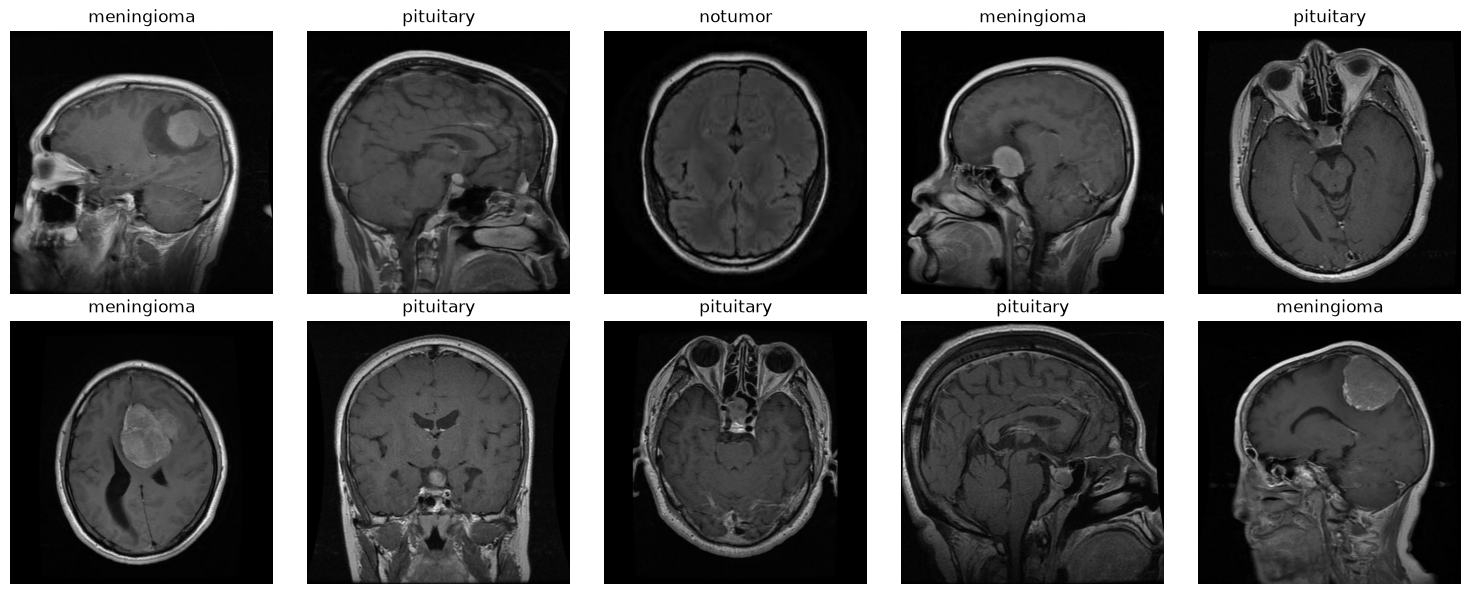

In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# transform to make all images 512x512 and convert to Tensors
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])

# load train and test dataset paths
train_path = 'brain_mri_dataset/Training/' 
test_path = 'brain_mri_dataset/Testing/'

# load train/test datasets and subfolder names
train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

# image data loading in batches
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)


# pulls batch of 10 images to display
images, labels = next(iter(train_loader))

# class names corresponding to the folder names
class_names = train_dataset.classes

# plot the first 10 images
fig, axes = plt.subplots(2, 5, figsize=(15,6))
axes = axes.flatten()

for i in range(10):
    # PyTorch images (Channels, Height, Width) --> Matplotlib images (Height, Width, Channels)
    img = images[i].permute(1, 2, 0).numpy()
    
    axes[i].imshow(img)
    axes[i].set_title(class_names[labels[i]])
    axes[i].axis('off')

plt.tight_layout()
plt.show()